# Wine Quality (Red Wine)

### 1. Giới thiệu về Dataset

**Tên dataset**: Wine Quality (Red Wine)  
**Nguồn gốc**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality) (Cortez et al., 2009)  

Bộ dữ liệu **Wine Quality** chứa thông tin về rượu vang đỏ thuộc dòng **Vinho Verde** - một loại rượu vang nổi tiếng của vùng miền Bắc Bồ Đào Nha. Dữ liệu được thu thập từ các mẫu rượu thực tế bởi Ủy ban Vinho Verde (CVRVV).

Mục đích chính của dataset là nghiên cứu mối quan hệ giữa các đặc tính hóa lý của rượu và điểm chất lượng cảm quan do con người đánh giá.

**Mỗi mẫu** trong dataset **đại diện** cho một **mẫu rượu vang đỏ Vinho Verde** đã được kiểm tra trong phòng thí nghiệm. Mỗi mẫu bao gồm 11 chỉ số hóa lý (physicochemical properties) được đo bằng thiết bị chuyên dụng và 1 điểm chất lượng (`quality`) do ban nếm thử chuyên nghiệp chấm dựa trên cảm quan (mùi, vị, màu sắc, cân bằng, hậu vị…).

Dataset gồm tổng cộng **1.599 mẫu** và **12 thuộc tính** (11 biến đầu vào + 1 biến đầu ra).

### 2. Ý nghĩa của từng cột

| STT | Tên cột                    | Ý nghĩa                                                                 | Đơn vị                          |
|-----|----------------------------|-------------------------------------------------------------------------|---------------------------------|
| 1   | fixed acidity             | Lượng axit cố định (chủ yếu axit tartaric), góp phần tạo vị chua và ổn định rượu | $g$(tartaric acid)$/dm^3$            |
| 2   | volatile acidity          | Lượng axit bay hơi (chủ yếu axit acetic), gây mùi giấm nếu quá cao     | $g$(acetic acid)$/dm^3$             |
| 3   | citric acid               | Axit citric, mang lại cảm giác tươi mới và cân bằng hương vị            | $g/dm^3$                           |
| 4   | residual sugar            | Lượng đường còn lại sau lên men, quyết định độ ngọt của rượu            | $g/dm^3$                           |
| 5   | chlorides                 | Hàm lượng muối (clorua), ảnh hưởng đến vị mặn và đắng                   | $g$(sodium chloride)$/dm^3$          |
| 6   | free sulfur dioxide       | $SO_2$ tự do, chất chống oxy hóa và kháng khuẩn                           | $mg/dm^3$                          |
| 7   | total sulfur dioxide      | Tổng lượng $SO_2$ (free + bound), đánh giá tổng chất bảo quản              | $mg/dm^3$                          |
| 8   | density                   | Mật độ của rượu, liên quan chặt chẽ với hàm lượng alcohol và đường     | $g/cm^3$                           |
| 9   | pH                        | Độ axit của rượu, ảnh hưởng đến độ chua và ổn định vi sinh             | pH                              |
| 10  | sulphates                 | Sunfat, có tác dụng bảo quản và tăng hương thơm                        | $g$(potassium sulfate)$/dm^3$        |
| 11  | alcohol                   | Hàm lượng cồn (rượu etylic), ảnh hưởng đến độ mạnh và hậu vị           | % vol.                          |
| 12  | quality                   | Điểm chất lượng cuối cùng do ban nếm thử chuyên nghiệp chấm            | Thang điểm từ 0 đến 10          |

**Lưu ý:**
- 11 cột đầu tiên là các biến **định lượng** được đo lường bằng phương pháp hóa lý.
- Cột `quality` là biến **định lượng rời rạc** (ordinal)..

### 3. Ai sẽ cần đến những phân tích này?

| Đối tượng                          | Tác dụng của phân tích thống kê                                                                 |
|------------------------------------|-------------------------------------------------------------------------------------------------------|
| **Nhà sản xuất rượu** | Giả sử việc biết được volatile acidity cao làm giảm quality hoặc alcohol và sulphates cao thường giúp quality tăng $\Rightarrow$ Điều chỉnh công thức lên men, thời gian ủ, lựa chọn giống nho để cải thiện chất lượng rượu. |
| **Bộ phận kiểm định chất lượng**       | Giám sát chất lượng rượu. Hỗ trợ xây dựng tiêu chuẩn benchmark cho từng chỉ số hóa lý. Phát hiện sớm các lô rượu có nguy cơ kém chất lượng qua outlier detection. |
| **Doanh nghiệp sản xuất & kinh doanh rượu** | Hiểu rõ điểm mạnh của sản phẩm (ví dụ: rượu có alcohol cao và citric acid tốt thường được chấm quality cao) $\Rightarrow$ Dùng để marketing, định giá và xây dựng câu chuyện thương hiệu. |
| **Tư vấn mua rượu** | Giải thích khoa học tại sao một chai rượu ngon hơn chai khác, hỗ trợ tư vấn cho khách hàng cao cấp. |
| **Nhà phân phối & Siêu thị rượu** | Phân khúc sản phẩm theo chất lượng, chọn lọc rượu chất lượng cao để nhập khẩu hoặc đẩy mạnh bán hàng. |

## I. Các đại lượng thống kê

In [103]:
# Nhập các thư viện cần thiết cho việc xử lý dữ liệu và trực quan hóa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Thêm thư mục gốc vào path để có thể import các module từ thư mục source
sys.path.append(os.path.abspath(".."))
from source import (
    mean, variance, standard_deviation, covariance, correlation, 
    distribution, dot_diagram, scatter_plot, box_plot
)

# Cấu hình style cho biểu đồ bằng Seaborn
sns.set_style("whitegrid")

# Tự động nạp lại các module khi có thay đổi trong mã nguồn
%reload_ext autoreload
%autoreload 2

In [104]:
try:
    # Đọc dữ liệu từ file CSV, ngăn cách bởi dấu chấm phẩy ';'
    df = pd.read_csv("../data/winequality-red.csv", sep=';')
    # Tách riêng các biến đặc trưng bằng cách loại bỏ cột mục tiêu 'quality'
    features = df.drop(columns=["quality"])
    print("Tải dữ liệu thành công.")
except FileNotFoundError:
    print("Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn.")

# Hiển thị 10 dòng đầu tiên để kiểm tra cấu trúc dữ liệu
df.head(10)

Tải dữ liệu thành công.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### 1. Tổng quan dữ liệu

In [105]:
# In ra kích thước và kiểu dữ liệu của các biến
print(f"Số lượng mẫu: {df.shape[0]}")
print(f"Số lượng biến: {features.shape[1]}")
print("-" * 30)
features.info()

Số lượng mẫu: 1599
Số lượng biến: 11
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
dtypes: float64(11)
memory usage: 137.5 KB


### 2. Mean và Variance

- **Mean ($\bar{x}$):** Đại diện cho giá trị trung tâm của tập dữ liệu.
  $$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$$
- **Variance ($s^2$):** Đo lường mức độ biến thiên hoặc phân tán của dữ liệu xung quanh giá trị trung bình. Trong thống kê mô tả, ta thường dùng phương sai mẫu có hiệu chỉnh ($n-1$):
  $$s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2$$

In [106]:
# Tính toán các đại lượng thống kê cơ bản cho từng cột bằng hàm tự viết
means = {col: mean(df[col]) for col in df.columns}
variances = {col: variance(df[col]) for col in df.columns}

# Tổng hợp kết quả vào một DataFrame để dễ quan sát
rows = []
for col in df.columns:
    rows.append({
        "Variable": col,
        "Mean": means[col],
        "Variance": variances[col],
    })

stats_df = pd.DataFrame(rows).set_index("Variable")
# Làm tròn đến 4 chữ số thập phân
stats_df.round(4)

,Mean,Variance
Variable,,
fixed acidity,8.3196,3.0314
volatile acidity,0.5278,0.0321
citric acid,0.2710,0.0379
residual sugar,2.5388,1.9879
chlorides,0.0875,0.0022
free sulfur dioxide,15.8749,109.4149
total sulfur dioxide,46.4678,1082.1024
density,0.9967,0.0000
pH,3.3111,0.0238


1. ***Nhìn vào Mean - Biến này đang ở mức nào?***

    Mean cho ta biết **giá trị trung bình** mà một mẫu rượu trong dataset có. Đây là điểm tham chiếu đầu tiên để hiểu "mặt bằng chung" của dữ liệu.

    | Biến | Mean | Đọc ra điều gì |
    |---|---|---|
    | fixed acidity | 8.32 g/dm³ | Lượng axit tartaric trung bình — nằm trong dải điển hình của rượu vang đỏ |
    | volatile acidity | 0.53 g/dm³ | Tiệm cận ngưỡng gây mùi giấm (thường > 0.6 bị coi là lỗi) — đây là tín hiệu đáng để ý |
    | citric acid | 0.27 g/dm³ | Khá thấp, nhiều mẫu gần 0 — axit citric không phải đặc trưng nổi bật của dòng này |
    | residual sugar | 2.54 g/dm³ | Thấp — rượu này thuộc dạng **dry wine**, không ngọt |
    | chlorides | 0.09 g/dm³ | Rất thấp — hàm lượng muối ở mức nền, không gây ảnh hưởng vị |
    | free SO₂ | 15.87 mg/dm³ | Dưới ngưỡng 50 mg/dm³ — đủ bảo quản nhưng không quá liều |
    | total SO₂ | 46.47 mg/dm³ | Ở mức trung bình so với tiêu chuẩn EU (max 160 mg/dm³ với red wine) |
    | density | 0.9967 g/cm³ | Gần bằng nước — hàm lượng cồn và đường không quá cao |
    | pH | 3.31 | Axit — điển hình cho rượu vang đỏ (thường trong khoảng 3.0–3.5) |
    | sulphates | 0.66 g/dm³ | Mức bình thường, đủ vai trò bảo quản và hỗ trợ hương |
    | alcohol | 10.42% vol | Độ cồn trung bình — không phải rượu nhẹ, cũng không phải nặng |
    | quality | 5.64 / 10 | Điểm cảm quan trung bình **hơi dưới 6** — phần lớn rượu trong dataset ở mức "bình thường", không xuất sắc |

    > Dataset này là tập hợp những chai rượu vang đỏ **phổ thông, khô, độ cồn vừa phải**, với chất lượng cảm quan chỉ ở mức trung bình. Không phải dataset của rượu cao cấp.

2. ***Nhìn vào Variance — Biến nào "ổn định", biến nào "loạn"?***

    Variance nói lên mức độ **biến động** của từng biến trong dataset. Variance thấp = các mẫu khá giống nhau ở chỉ số đó. Variance cao = có sự phân tán lớn, tức là có những mẫu khác biệt đáng kể so với giá trị trung bình.

    - Nhóm biến có variance cực thấp ($\approx$ 0) — "Biến ổn định"

        | Biến | Variance | Ý nghĩa |
        |---|---|---|
        | density | 0.0000 | Gần như mọi mẫu rượu đều có density y hệt nhau — biến này **gần như không mang thông tin phân biệt** |
        | chlorides | 0.0022 | Hàm lượng muối rất đồng đều — ít có mẫu bất thường |
        | volatile acidity | 0.0321 | Tương đối đồng nhất, nhưng vì mean đã tiệm cận ngưỡng lỗi nên vẫn cần để ý |
        | pH | 0.0238 | Độ axit rất ổn định giữa các mẫu |

    > Những biến có variance gần 0 (đặc biệt là `density`) sẽ **không đóng góp nhiều vào mô hình phân loại** vì chúng không giúp phân biệt mẫu này với mẫu kia.

    - Nhóm biến có variance trung bình — "Biến có biến động vừa phải"

        | Biến | Variance |
        |---|---|
        | citric acid | 0.0379 |
        | sulphates | 0.0287 |
        | residual sugar | 1.9879 |
        | alcohol | 1.1356 |
        | fixed acidity | 3.0314 |
        | quality | 0.6522 |

        Đặc biệt, **`quality` có variance 0.65** — điểm chất lượng không phân tán nhiều, tức là hầu hết rượu trong dataset xếp vào nhóm 5–6 điểm. Dataset này **thiếu sự đa dạng về chất lượng** (ít mẫu rượu rất tệ hoặc rất tốt).

    - Nhóm biến có variance cực cao — "Biến loạn nhất"

        | Biến | Variance | Tại sao quan trọng |
        |---|---|---|
        | **total $SO_2$** | **1082.10** | Một số mẫu có $SO_2$ rất cao, một số rất thấp — phân tán cực mạnh |
        | **free $SO_2$** | **109.41** | Tương tự, nhưng ở mức thấp hơn |

    > Hai biến $SO_2$ này có variance lớn **không phải vì đơn vị đo (mg/dm³) khác biệt**, mà thực sự có những mẫu ngoại lai với $SO_2$ rất cao. Nếu dùng các thuật toán nhạy cảm với scale (kNN, SVM, Linear Regression...), ta **bắt buộc phải chuẩn hóa** những biến này — nếu không, chúng sẽ "lấn át" tất cả các biến khác.

**Kết luận:**

  - **Dataset này cần chuẩn hóa trước khi modeling:** Các biến có đơn vị và variance chênh lệch nhau quá lớn ($SO_2$ variance ~1082 vs density ~0.000). **Min-max scaling hoặc standardization (z-score) là bắt buộc** nếu dùng các mô hình dựa trên khoảng cách hay gradient.

  - **Vấn đề class imbalance tiềm ẩn trong biến `quality`:** Mean = 5.64 và Variance = 0.65 cho thấy điểm chất lượng tập trung quanh 5–6. Khi chuyển sang bài toán phân loại (ví dụ: tốt vs không tốt), có thể sẽ có rất ít mẫu ở điểm 3, 4, hoặc 8, 9.

  - **`density` có thể loại bỏ sớm:** Variance ≈ 0 đồng nghĩa với việc biến này không mang khả năng phân biệt giữa các mẫu. Đây là ứng viên đầu tiên để loại bỏ trong bước **feature selection**.

### 3. Phân tích tương quan

In [107]:
# Khởi tạo ma trận rỗng dựa trên số lượng biến
var_list = df.columns.tolist()
p = len(var_list)

cov_matrix = np.zeros((p, p))
corr_matrix = np.zeros((p, p))

# Duyệt vòng lặp để tính toán từng cặp biến
for i, vi in enumerate(var_list):
    for j, vj in enumerate(var_list):
        # Tính hiệp phương sai mẫu (Bessel correction)
        cov_matrix[i, j] = covariance(df[vi], df[vj], is_population=False)
        # Tính hệ số tương quan Pearson
        corr_matrix[i, j] = correlation(df[vi], df[vj])

#### 3.1 Covariance Matrix

- **Hiệp phương sai ($cov(X, Y)$):** Đo lường mối quan hệ tuyến tính giữa hai biến định lượng. 
  - $cov > 0$: Hai biến có xu hướng tăng/giảm cùng chiều.
  - $cov < 0$: Hai biến có xu hướng ngược chiều.
  $$cov(X, Y) = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

- Giá trị trên đường chéo chính là **phương sai** của từng biến.

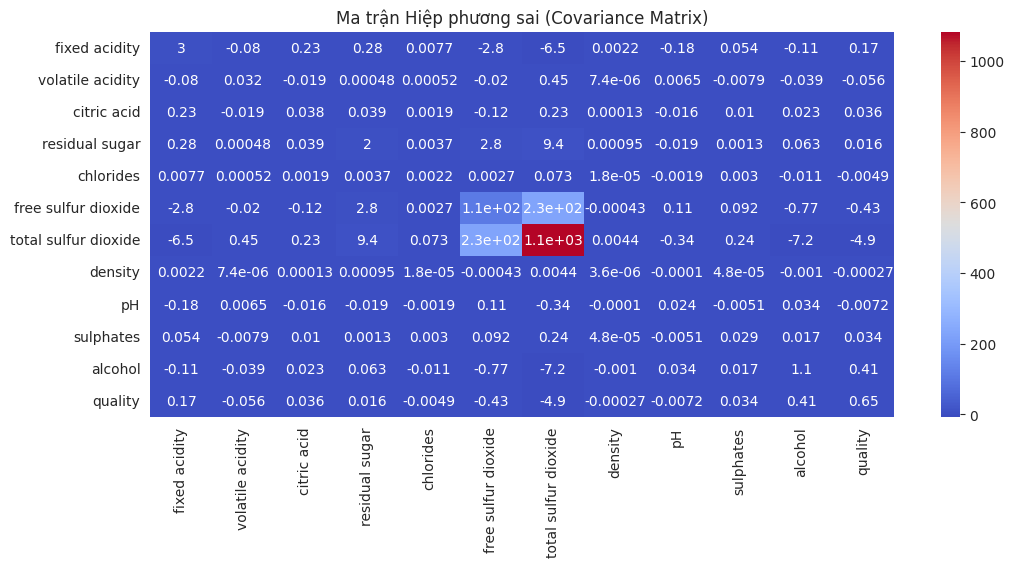

In [108]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
# Vẽ bản đồ nhiệt để quan sát mức độ biến động cùng chiều/ngược chiều
sns.heatmap(cov_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm")
plt.title("Ma trận Hiệp phương sai (Covariance Matrix)")
plt.show()

1. ***Đọc ma trận này để làm gì?***
 
    Nếu Mean và Variance mô tả **từng biến riêng lẻ**, thì Covariance Matrix mô tả **mối quan hệ giữa các cặp biến** — cụ thể là khi một biến tăng, biến kia có xu hướng tăng theo, giảm theo, hay không liên quan gì?

2. ***Những cặp quan hệ đáng chú ý:***
 
- **Quan hệ cùng chiều mạnh (covariance dương, lớn)**
 
    **`free SO₂` - `total SO₂` = 230**
 
    Đây là cặp có covariance lớn nhất trong toàn bộ ma trận. Điều này hoàn toàn hợp lý về mặt hóa học — `free SO₂` là một thành phần nằm trong `total SO₂`, nên hai biến này **về bản chất là không độc lập**. Khi một nhà sản xuất thêm nhiều SO₂ vào rượu, cả hai chỉ số đều tăng cùng nhau.
    
    **`fixed acidity` - `residual sugar` = 0.28** và **`residual sugar` - `total SO₂` = 9.4**
    
    Hai cặp này có covariance dương nhỏ — gợi ý một xu hướng nhẹ: rượu có nhiều axit hoặc đường hơn đi kèm với lượng SO₂ cao hơn, có thể do những loại rượu này cần bảo quản kỹ hơn.
 
- **Quan hệ ngược chiều đáng chú ý (covariance âm)**
 
    **`fixed acidity` - `total SO₂` = −6.5**
    
    Ngược chiều khá rõ — rượu có độ axit cố định cao thường có tổng SO₂ thấp hơn. Axit tartaric bản thân đã có tác dụng ức chế vi khuẩn, nên ít cần dùng SO₂ hơn để bảo quản.
    
    **`alcohol` - `free SO₂` = −0.77** và **`alcohol` - `total SO₂` = −7.2**
    
    Rượu có độ cồn cao hơn đi kèm với SO₂ thấp hơn — cồn cũng là chất bảo quản tự nhiên, nên rượu mạnh hơn cần ít SO₂ hơn. Đây là quan hệ có ý nghĩa thực tế rõ ràng.
    
    **`fixed acidity` - `pH` = −0.18**
    
    Chiều âm đúng như kỳ vọng — axit càng nhiều thì pH càng thấp (càng chua). Đây là mối quan hệ **tất yếu về mặt hóa học**, không phải phát hiện mới, nhưng việc nó xuất hiện trong dữ liệu thực là dấu hiệu tốt cho thấy dữ liệu nhất quán.

- **Quan hệ gần như không có (covariance ≈ 0)**
 
    `density` với hầu hết các biến đều có covariance cực nhỏ (7.4e-06, 1.8e-05...) — nhất quán với việc `density` có variance gần 0 như đã phân tích. Biến này không biến động, nên tự nhiên không có quan hệ tuyến tính rõ ràng với các biến khác.

- **`quality` — biến mục tiêu nói gì?**
    
    Nhìn vào hàng/cột `quality`, hai giá trị nổi bật nhất là **`alcohol` ↔ `quality` = 0.41** (cùng chiều) và **`volatile acidity` ↔ `quality` = −0.056** (ngược chiều). Tuy nhiên vì covariance phụ thuộc đơn vị, không thể kết luận cái nào "mạnh hơn" chỉ từ con số này — cần nhìn sang Correlation Matrix để so sánh công bằng.
 
3. ***Hạn chế của Covariance Matrix***
 
    Nhìn vào ma trận này, có một vấn đề rõ ràng: **màu sắc heatmap bị chi phối hoàn toàn bởi cặp free/total SO₂** (covariance = 230 và 1082 trên đường chéo), khiến tất cả các cặp còn lại trông gần như bằng 0 và khó phân biệt.
    
    Đây chính là giới hạn của covariance khi các biến có đơn vị đo khác nhau — **con số to không có nghĩa là quan hệ mạnh hơn**. Để trả lời câu hỏi "cặp biến nào thực sự có quan hệ chặt chẽ nhất?", cần chuẩn hóa covariance về thang [-1, 1] — tức là chuyển sang **Correlation Matrix**.
    
    > Ma trận này cho thấy **chiều** của các mối quan hệ, và hầu hết đều có lý giải hóa học/thực tiễn rõ ràng. Tuy nhiên, để so sánh **mức độ mạnh yếu** giữa các cặp một cách công bằng, covariance không đủ — đó là lý do Correlation Matrix tồn tại.

#### 3.2 Correlation Matrix

- **Hệ số tương quan Pearson ($r$):** Chuẩn hóa hiệp phương sai về khoảng $[-1, 1]$ để so sánh mức độ mạnh yếu của mối quan hệ tuyến tính mà không phụ thuộc vào đơn vị đo.
  $$r_{XY} = \frac{cov(X, Y)}{s_X s_Y}$$
  Trong đó $s_X, s_Y$ là độ lệch chuẩn của $X$ và $Y$.

  - $|r| \approx 1$: Tương quan tuyến tính mạnh
  - $|r| \approx 0$: Gần như không có quan hệ tuyến tính
  - $r \ge 0$: Cùng chiều — biến này tăng thì biến kia cũng tăng
  - $r \le 0$: Ngược chiều — biến này tăng thì biến kia giảm

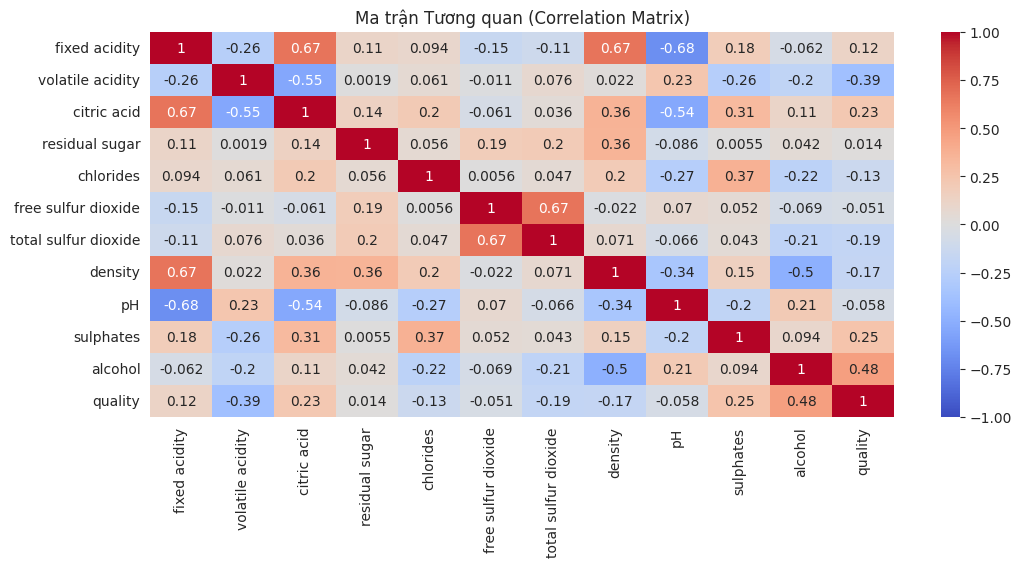

In [109]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
# Vẽ tương quan trong khoảng [-1, 1] để so sánh công bằng giữa các biến
sns.heatmap(corr_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Ma trận Tương quan (Correlation Matrix)")
plt.show()

1. ***Những cặp tương quan mạnh $(|r| \ge 0.5)$***

- `fixed acidity` - `citric acid` = 0.67 $\rightarrow$ Cùng chiều
 
    Rượu có nhiều axit tartaric thường cũng có nhiều axit citric — cả hai đều là axit không bay hơi, được đưa vào cùng nhau trong quá trình điều chỉnh độ chua của rượu. Quan hệ này phản ánh **thực hành sản xuất có chủ đích**, không phải ngẫu nhiên.

- `fixed acidity` - `density` = 0.67 $\rightarrow$ Cùng chiều
 
    Rượu có nhiều axit hơn có xu hướng đặc hơn — axit tartaric có khối lượng phân tử cao hơn nước, nên hàm lượng axit cao làm tăng mật độ dung dịch. Đây là quan hệ có cơ sở vật lý rõ ràng.    

- `free SO₂` - `total SO₂` = 0.67 $\rightarrow$ Cùng chiều
    
    Đã giải thích ở covariance — đây là quan hệ cấu trúc, `free SO₂` là thành phần của `total SO₂`. Điểm mới khi nhìn ở correlation: r = 0.67 chứ không phải gần 1.0, tức là **phần SO₂ bị "bound"** (liên kết với các phân tử khác) biến động đáng kể giữa các mẫu, không cố định.    
 
- `fixed acidity` - `pH` = −0.68 $\rightarrow$ Ngược chiều
 
    Tương quan âm mạnh nhất liên quan đến `fixed acidity`. Axit càng nhiều thì pH càng thấp — đây là **mối quan hệ tất yếu về hóa học**. Sự xuất hiện rõ ràng trong dữ liệu thực xác nhận rằng các phép đo trong dataset nhất quán và đáng tin cậy.
 
- `citric acid` - `volatile acidity` = −0.55 $\rightarrow$ Ngược chiều
 
    Rượu có nhiều axit citric thường ít axit acetic (mùi giấm) hơn. Axit citric ức chế hoạt động của vi khuẩn acetic — đây là **cơ chế bảo vệ tự nhiên** trong rượu vang. Đây là một trong những cặp thú vị nhất vì nó gợi ý: kiểm soát tốt axit citric có thể là cách gián tiếp giảm nguy cơ rượu bị lỗi mùi giấm.
    
- `citric acid` - `pH` = −0.54 $\rightarrow$ Ngược chiều
    
    Tương tự `fixed acidity` — axit citric cũng góp phần làm giảm pH. Độ mạnh ~0.54 cho thấy `citric acid` đóng góp đáng kể vào độ chua tổng thể của rượu, dù không phải yếu tố duy nhất.
    
- `density` - `alcohol` = −0.50 $\rightarrow$ Ngược chiều
    
    Rượu có độ cồn cao hơn thì nhẹ hơn (density thấp hơn) — cồn ethanol có khối lượng riêng thấp hơn nước, nên rượu càng mạnh càng có xu hướng ít đặc hơn. Đây là quan hệ vật lý trực tiếp và là một trong những tương quan rõ nhất trong dataset.
 
1. ***Những cặp tương quan trung bình đáng để ý $(0.3 \le |r| \le 0.5)$***
 
    | Cặp biến | r | Đọc ra điều gì |
    |---|---|---|
    | `citric acid` - `density` | 0.36 | Axit citric góp phần làm tăng mật độ, dù yếu hơn `fixed acidity` |
    | `residual sugar` - `density` | 0.36 | Đường còn lại làm rượu đặc hơn — đúng về mặt vật lý |
    | `chlorides` - `sulphates` | 0.37 | Hai chất khoáng có xu hướng xuất hiện cùng nhau — có thể liên quan đến nguồn nước hoặc đặc tính đất trồng nho |
    | `volatile acidity` - `pH` | 0.23 | Rượu càng ít chua (pH cao hơn) thì nguy cơ lên men acetic càng cao — môi trường ít axit thuận lợi hơn cho vi khuẩn acetic |
 
2. ***Những cặp gần như không có tương quan $(|r| \le 0.1)$***
 
    `residual sugar` với hầu hết các biến đều có r rất thấp (0.0019, 0.056, 0.042...) — lượng đường còn lại **gần như độc lập** với phần lớn các chỉ số hóa lý khác. Điều này hợp lý vì đây là rượu dry wine — đường thấp và ít biến động, nên không tạo ra tương quan rõ với các biến khác.

3. ***`quality` — biến mục tiêu liên quan đến gì?***
 
    Đây là phần quan trọng nhất vì nó trả lời câu hỏi trung tâm: **đặc tính hóa lý nào thực sự liên quan đến chất lượng cảm quan?**
    
    | Biến | r với quality | Chiều | Đọc ra điều gì |
    |---|---|---|---|
    | **alcohol** | **0.48** | cùng chiều | Biến có tương quan mạnh nhất với quality — rượu càng nhiều cồn càng được đánh giá cao hơn |
    | **volatile acidity** | **−0.39** | ngược chiều | Mùi giấm càng cao thì điểm càng thấp — đúng như kỳ vọng về mặt cảm quan |
    | sulphates | 0.25 | cùng chiều | Sunfat cao hơn đi kèm chất lượng tốt hơn nhẹ — sulphates hỗ trợ hương và bảo quản |
    | citric acid | 0.23 | cùng chiều | Axit citric mang lại cảm giác tươi mới, gợi ý đây là yếu tố tích cực nhẹ |
    | total SO₂ | −0.19 | ngược chiều | SO₂ quá nhiều ảnh hưởng tiêu cực đến cảm quan — mùi hóa chất |
    | chlorides | −0.13 | ngược chiều | Vị mặn cao hơn đi kèm điểm thấp hơn |
    | density | −0.17 | ngược chiều | Rượu đặc hơn (thường ít cồn hơn) được đánh giá thấp hơn |
    | residual sugar | 0.014 | — | Gần như không có quan hệ với quality trong dataset này |
    | pH | −0.058 | — | Độ chua tổng thể gần như không ảnh hưởng trực tiếp đến điểm |
    
    > **Điểm đáng chú ý:** Không có biến nào có $|r| \ge 0.5$ với `quality` — tức là **không có một yếu tố đơn lẻ nào quyết định trực tiếp đến chất lượng rượu**. Điểm cảm quan là kết quả của sự kết hợp nhiều yếu tố, không phải một chỉ số duy nhất.

4. ***Tổng hợp***
 
    Nhìn toàn bộ ma trận, có thể nhóm lại thành **2 nhóm quan hệ chính**:
 
    **Nhóm 1 — Quan hệ hóa học/vật lý tất yếu:** `fixed acidity` - `pH`, `fixed acidity` - `density`, `density` - `alcohol`, `free SO₂` - `total SO₂`. Những cặp này có tương quan mạnh và đều có lý giải khoa học rõ ràng — chúng xác nhận dataset phản ánh đúng thực tế, đo lường nhất quán.
    
    **Nhóm 2 — Quan hệ liên quan đến chất lượng rượu:** `citric acid` - `volatile acidity` (−0.55) là cặp thú vị nhất — gợi ý rằng axit citric đóng vai trò bảo vệ chống lại sự hình thành mùi giấm. Đây là tín hiệu đáng được phân tích sâu hơn khi xem xét tương quan với `quality`.

    **Nhóm 3 — Quan hệ với biến mục tiêu `quality`:** `alcohol` (0.48) và `volatile acidity` (−0.39) là hai biến có tương quan rõ nhất với điểm chất lượng. Tuy nhiên cả hai đều ở mức trung bình — chất lượng rượu là kết quả đa yếu tố, không có một chỉ số nào chiếm ưu thế tuyệt đối.
    
    > Các biến trong dataset **không độc lập với nhau** — có những cụm biến liên kết chặt theo cơ chế hóa lý. Điều này quan trọng khi diễn giải kết quả: nếu một biến thay đổi, nó thường kéo theo một vài biến khác thay đổi cùng, chứ không phải đơn lẻ.

## II. Trục quan hóa

### 1. Phân phối của các biến

Biểu đồ phân phối (histogram + đường KDE) cho thấy hình dạng phân phối của từng biến — dữ liệu tập trung ở đâu, trải rộng đến đâu, và có xuất hiện giá trị bất thường không, phân phối có đối xứng hay không.

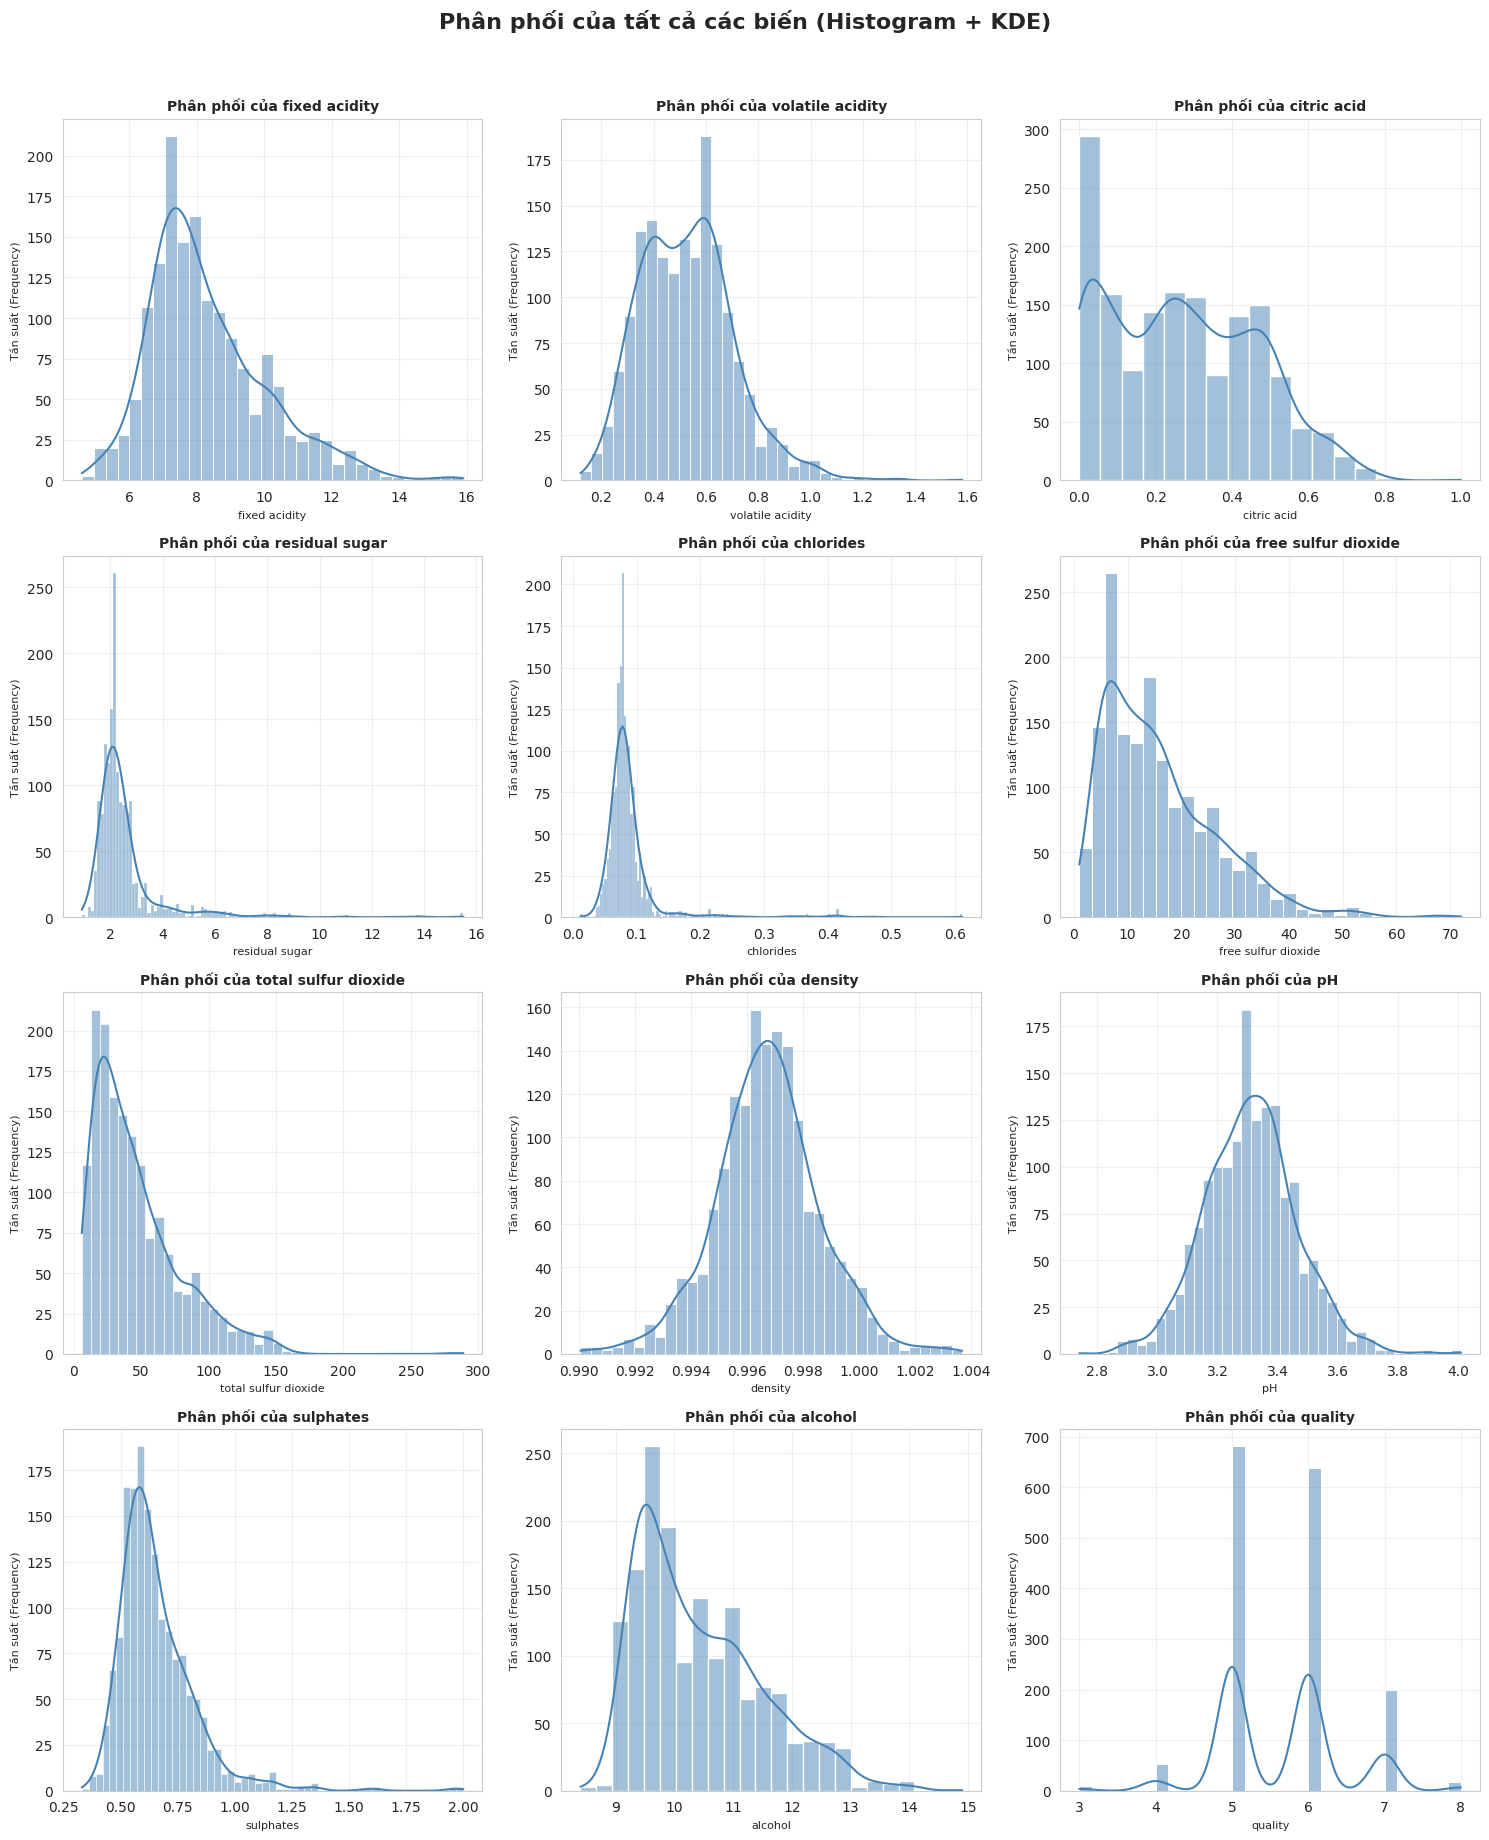

In [110]:
# Vẽ phân phối cho toàn bộ các cột (bao gồm cả quality)
plt.figure(figsize=(15, 18))
for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1)
    # Hàm kết hợp biểu đồ cột tần suất và đường cong mật độ mượt
    distribution(df, col)
plt.suptitle("Phân phối của tất cả các biến (Histogram + KDE)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

1. ***Nhóm 1 — Phân phối gần chuẩn***

    `density` và `pH` $\rightarrow$ Phân phối đối xứng, gần chuẩn
 
    Hai biến này có phân phối **đối xứng, một đỉnh rõ ràng**, KDE khớp tốt với histogram. Đây là những biến ổn định nhất trong dataset — phân phối tập trung, ít nhiễu, ít outlier. Nhất quán với variance cực thấp đã phân tích trước đó.

    `fixed acidity` và `volatile acidity` $\rightarrow$ Gần chuẩn, lệch phải nhẹ
 
    Gần chuẩn nhưng **lệch phải nhẹ** — có đuôi dài về phía giá trị cao. Tức là phần lớn mẫu rượu nằm ở vùng axit trung bình, nhưng có một nhóm nhỏ các mẫu có độ axit cao bất thường. Với `volatile acidity`, điều này đáng lo hơn vì những mẫu ở đuôi phải (> 1.0) gần như chắc chắn bị lỗi mùi giấm.

1. ***Nhóm 2 — Phân phối lệch phải mạnh***

    `residual sugar`, `chlorides`, `sulphates` $\rightarrow$ Lệch phải mạnh
 
    Cả ba đều có hình dạng tương tự: **đỉnh cao ở bên trái, đuôi kéo dài về phía phải**. Phần lớn mẫu tập trung ở giá trị thấp, nhưng có một số mẫu có giá trị cao bất thường — đây là dấu hiệu rõ ràng của **outlier**. Đặc biệt `chlorides` và `residual sugar` có đuôi rất dài so với phần thân chính của phân phối — những mẫu ở đuôi này là các chai rượu có đặc tính hóa lý khác hẳn phần còn lại.

    `free SO₂` và `total SO₂` $\rightarrow$ Lệch phải rất mạnh, có outlier nghiêm trọng
    
    Lệch phải mạnh nhất trong toàn bộ dataset. Histogram cho thấy phần lớn mẫu tập trung ở giá trị thấp (free $SO_2$ < 20, total $SO_2$ < 50), nhưng có những mẫu kéo dài đến tận 70 và 300 — **khoảng cách rất lớn**. KDE bị kéo theo và không thể hiện tốt vùng tập trung chính. Đây là những biến có outlier nghiêm trọng nhất, nhất quán với variance cực cao đã phân tích.

1. ***Nhóm 3 — Phân phối đặc biệt, cần chú ý riêng***

    `citric acid` $\rightarrow$ Phân phối bất thường
 
    Đây là biến thú vị nhất khi nhìn vào phân phối. Có một cột rất cao tập trung ở **gần 0** — tức là rất nhiều mẫu rượu gần như không có axit citric. Sau đó phân phối trải ra tương đối phẳng đến khoảng 0.5, rồi có một đỉnh nhỏ nữa ở ~0.5. Hình dạng này **không giống bất kỳ phân phối chuẩn nào** — KDE cũng không thể hiện tốt cột cao ở 0. Điều này gợi ý rằng có hai nhóm rượu trong dataset: nhóm không dùng axit citric và nhóm có bổ sung axit citric vào rượu.

    `volatile acidity` $\rightarrow$ Phân phối 2 đỉnh (bimodal)
 
    KDE cho thấy rõ **2 đỉnh** — một ở ~0.4 và một ở ~0.6. Histogram xác nhận đây là thực tế trong dữ liệu, không phải do KDE ước lượng sai. Hai đỉnh này gợi ý có **2 nhóm rượu khác nhau** về mức độ axit bay hơi — có thể phản ánh 2 phong cách sản xuất hoặc 2 nguồn nguyên liệu khác nhau.

    `alcohol` $\rightarrow$ Phân phối dạng bậc thang
 
    Histogram cho thấy phân phối có dạng **bậc thang không đều** — có vài bin cao hơn hẳn xung quanh (~9.5 và ~10.5), tạo ra hình răng cưa mà KDE làm mượt đi. Điều này có thể do nhà sản xuất có xu hướng **làm tròn độ cồn** về các mức cố định khi ghi nhãn, hoặc do quy trình lên men có những ngưỡng kết thúc tự nhiên.

1. ***Nhóm 4 — `quality`: biến rời rạc trong một dataset liên tục***
 
    `quality` là biến duy nhất trong dataset **không phải kiểu dữ liệu số thực** — nó chỉ nhận các giá trị nguyên từ 3 đến 8, do ban nếm thử chấm điểm. Điều này tạo ra một số điểm cần chú ý khi nhìn vào biểu đồ:
    
    - Chỉ có 6 cột tương ứng với 6 mức điểm, và hai cột cao nhất là **5 và 6** (chiếm phần lớn tuyệt đối trong dataset). Điểm 3 và 8 gần như không có — dataset cực kỳ mất cân bằng giữa các mức chất lượng.
    
    - Nhìn vào histogram `quality`, thông tin quan trọng nhất là: **hơn 80% mẫu rượu trong dataset nằm ở điểm 5 và 6** — xác nhận lại nhận định từ phần mean/variance rằng đây là dataset của rượu phổ thông, không có nhiều mẫu ở hai đầu cực (rất tệ hoặc rất tốt).

2. ***Tổng hợp***

    **Hầu hết các biến đều lệch phải** — đây là đặc điểm phổ biến của dữ liệu hóa lý trong thực tế. Giá trị mean bị kéo về phía đuôi phải, nên mean không đại diện tốt cho "mẫu điển hình" ở những biến này — median sẽ sát thực hơn.

    **Outlier xuất hiện ở hầu hết các biến**, đặc biệt $SO_2$, chlorides, residual sugar. Những mẫu ở đuôi phân phối không phải lỗi đo lường — chúng là những chai rượu thực sự có đặc tính hóa lý khác biệt, và cần được xem xét riêng khi phân tích sâu hơn.

    **`citric acid` và `volatile acidity`** là hai biến có phân phối bất thường nhất — cả hai đều gợi ý sự tồn tại của các nhóm con trong dataset, không phải một quần thể đồng nhất.

### 2. Dot Diagrams

Dot diagram và histogram cùng mô tả phân phối, nhưng có một điểm khác biệt quan trọng: **histogram gộp dữ liệu vào các bin** — ta chỉ thấy tần suất của từng khoảng, không thấy từng điểm dữ liệu riêng lẻ. Dot diagram trải từng điểm ra trên một trục ngang, cho phép nhìn thấy trực tiếp **mật độ tập trung, khoảng trống, và vị trí chính xác của các điểm ngoại lai** mà histogram che khuất bằng cách gộp bin.

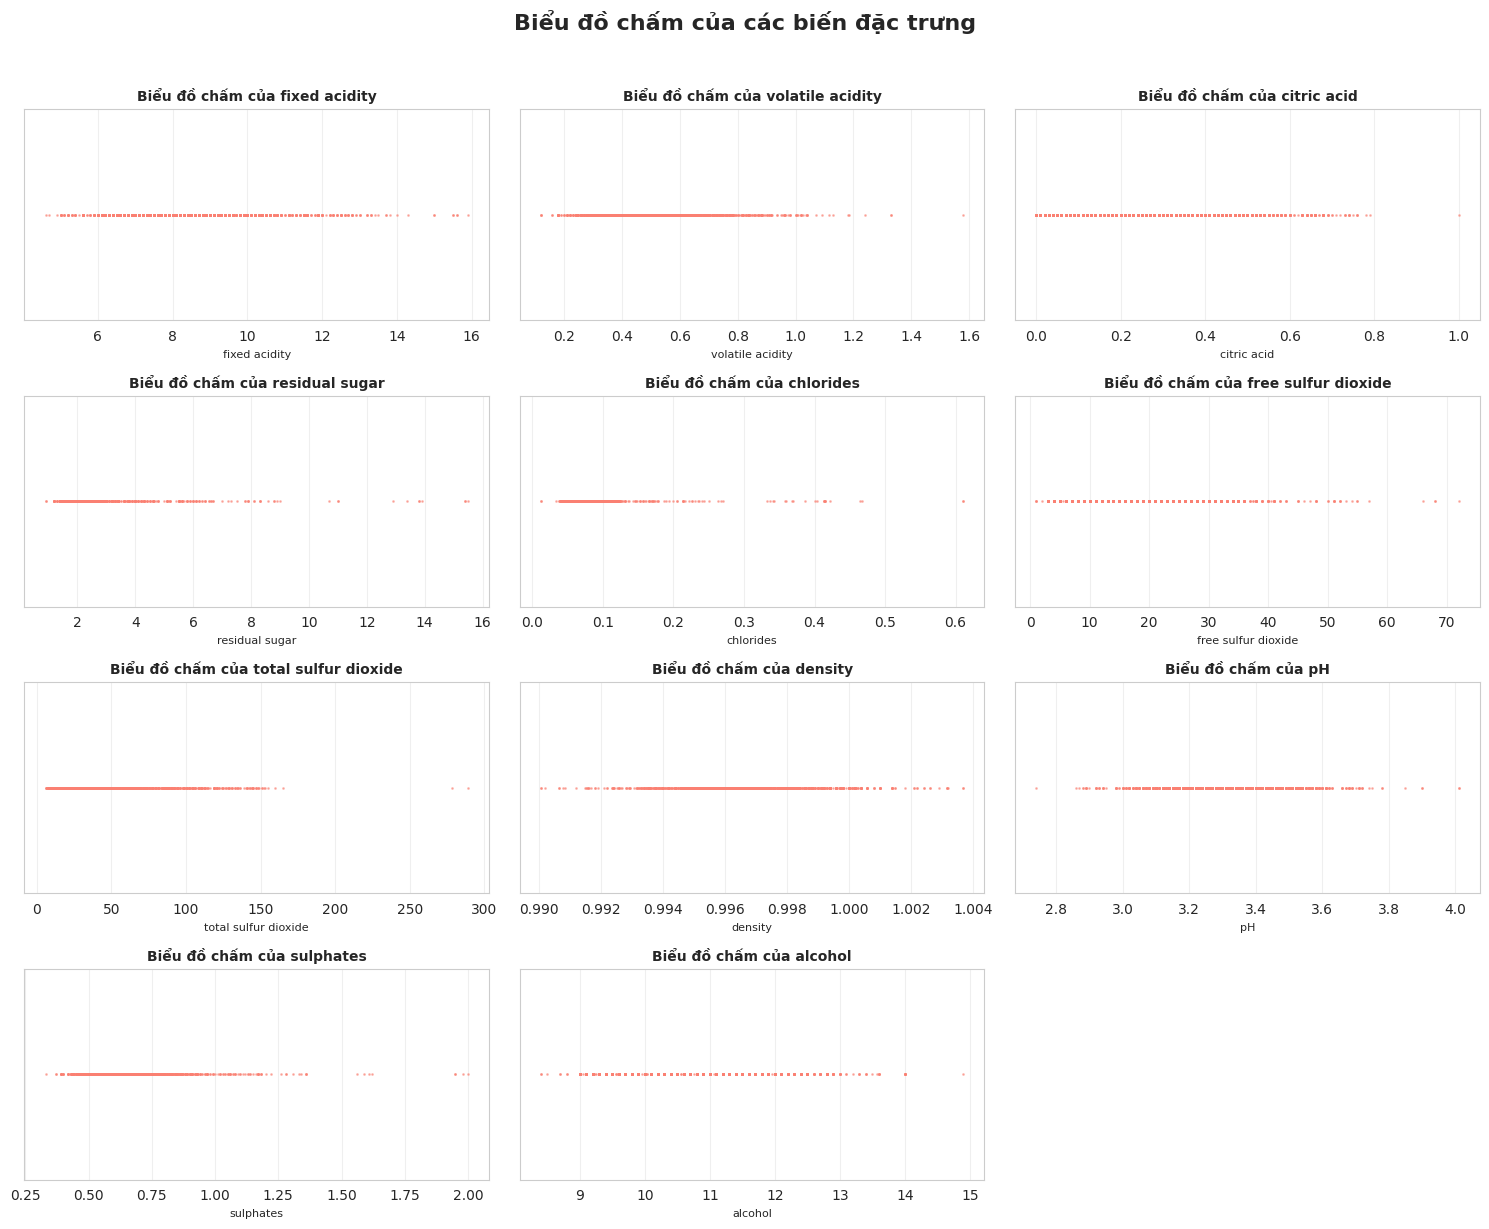

In [111]:
# Vẽ biểu đồ 1 chiều để quan sát chính xác vị trí các điểm outlier
plt.figure(figsize=(15, 12))
for i, col in enumerate(features.columns):
    plt.subplot(4, 3, i + 1)
    dot_diagram(features, col)
plt.suptitle("Biểu đồ chấm của các biến đặc trưng", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

1. ***Outlier hiện ra rõ hơn***

    `residual sugar`, `chlorides`, `sulphates` $\rightarrow$ Outlier thưa và tách biệt rõ
    
    Histogram cho thấy đuôi phải dài, nhưng dot diagram cho thấy rõ hơn rằng **những điểm ở đuôi đó thực sự rất thưa thớt và cách xa phần còn lại** — không phải một vùng dữ liệu liên tục mà là vài điểm đơn lẻ bị kéo ra xa. Đây là sự khác biệt có ý nghĩa: outlier kiểu này không phải một nhóm, mà là các mẫu thực sự bất thường.

    `volatile acidity` $\rightarrow$ Outlier cực đoan ở đuôi phải
       
    Histogram cho thấy đuôi phải kéo đến ~1.6, nhưng dot diagram cho thấy sau khoảng 1.2 chỉ còn **lác đác 2–3 điểm rất cô lập** — những chai rượu này có mức axit acetic cao bất thường so với toàn bộ dataset.


2. ***Vùng tập trung chính hiện ra sắc nét hơn***

    `density` và `pH` $\rightarrow$ Vùng tập trung rất hẹp, mật độ cao
    
    Phần dày đặc nhất của các chấm tập trung rất hẹp ở giữa — nhất quán với variance thấp đã phân tích. Dot diagram xác nhận trực quan điều mà con số đã nói: gần như mọi mẫu rượu đều có density và pH rất gần nhau.

    `fixed acidity` $\rightarrow$ Ranh giới tự nhiên của vùng "bình thường"
    
    Phần dày đặc nằm trong khoảng 6–10, sau đó thưa dần — dot diagram cho thấy rõ **ranh giới tự nhiên** của vùng "bình thường" trước khi đuôi phải bắt đầu.

3. ***Khoảng trống trong dữ liệu***

    `total sulfur dioxide` $\rightarrow$ Khoảng trống trước outlier
 
    Phần dày đặc kết thúc khá đột ngột ở ~150, sau đó có **khoảng trống rõ ràng** trước khi xuất hiện 2–3 điểm ngoại lai ở 280–300. Histogram gộp bin dễ che khuất khoảng trống này. Đây là tín hiệu cho thấy những mẫu đó thực sự là outlier tách biệt, không phải phần tiếp nối tự nhiên của phân phối.

4. ***Tổng hợp***

    Nhìn tổng thể 11 biểu đồ, **tất cả các biến đều có cấu trúc tương tự**: một vùng dày đặc ở giữa/trái, và một số điểm rải rác ở đuôi phải.

    Dot diagram giúp người đọc thấy rõ rằng **outlier trong dataset này không phải các nhóm nhỏ mà là các điểm đơn lẻ thực sự tách biệt** — không có ranh giới mờ giữa "bình thường" và "bất thường", mà là khoảng cách rõ ràng.

### 3. Box Plots theo biến `quality`

Correlation matrix cho biết **quan hệ có cường độ như nào** giữa biến hóa lý và `quality`. Box plot trả lời câu hỏi tiếp theo: **quan hệ đó trông như thế nào cụ thể ở từng mức điểm?** Median của mỗi nhóm dịch chuyển theo chiều nào? IQR của các nhóm có chồng lên nhau không? Outlier tập trung ở nhóm nào?

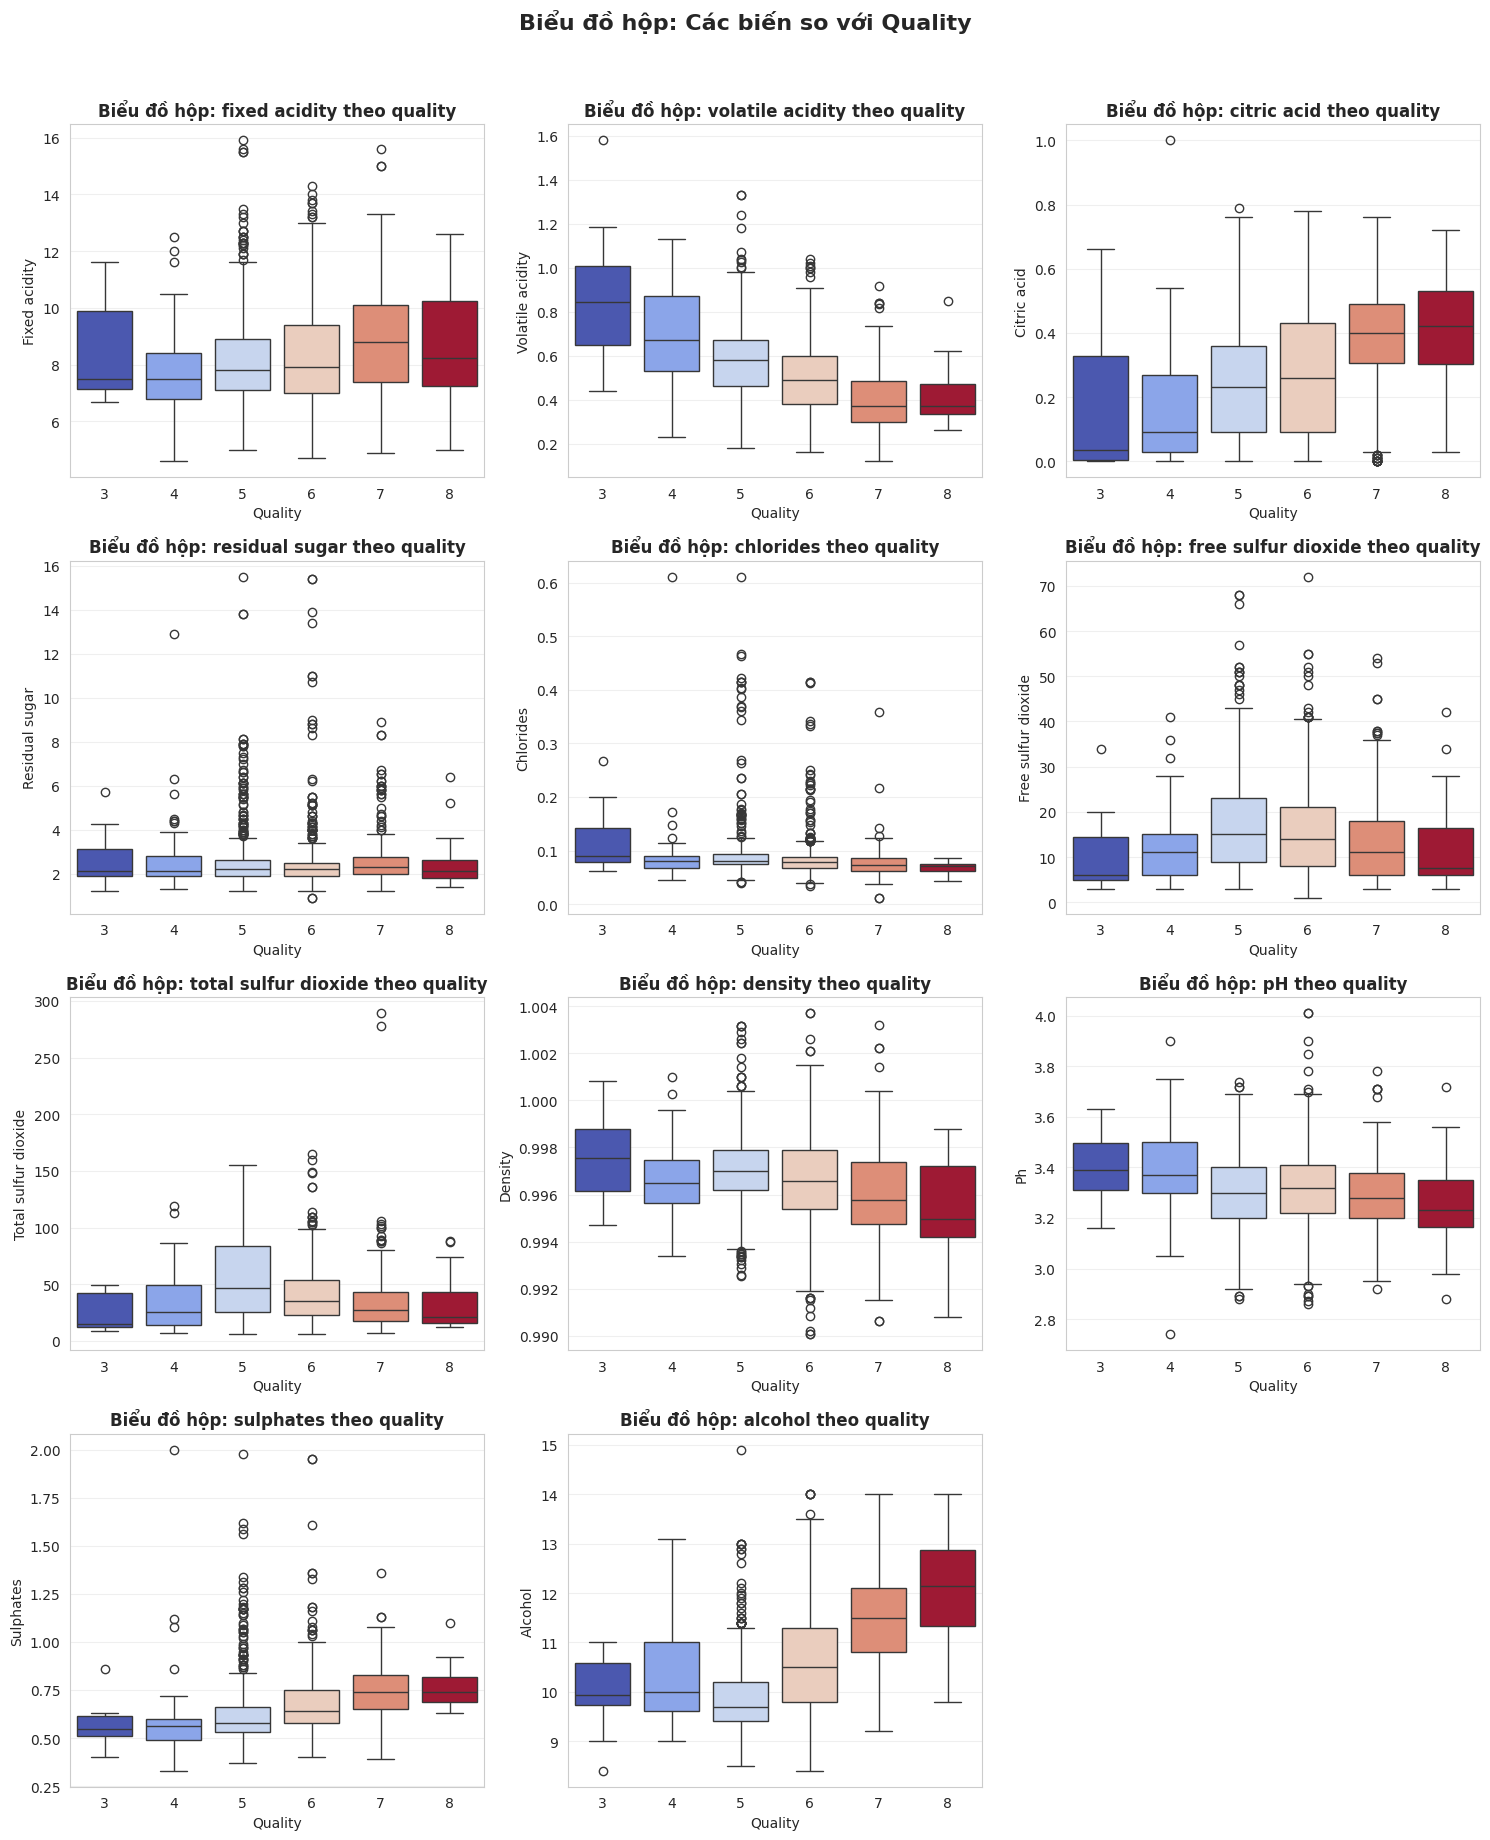

In [112]:
# So sánh phân phối các biến hóa lý qua từng mức điểm chất lượng
plt.figure(figsize=(15, 18))
for i, col in enumerate(features.columns):
    plt.subplot(4, 3, i + 1)
    # Dùng Box Plot để thấy rõ xu hướng tăng/giảm và trung vị (median)
    box_plot(df, "quality", col)
plt.suptitle("Biểu đồ hộp: Các biến so với Quality", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

1. ***Nhóm 1 — Xu hướng rõ ràng theo quality***

    `alcohol` $\rightarrow$ Tăng dần mạnh theo quality
 
    Đây là biến thể hiện xu hướng rõ ràng nhất trong toàn bộ 11 biểu đồ. Median tăng đều từ điểm 4 (~10%) lên điểm 8 (~12%), và quan trọng hơn: **IQR của nhóm 7–8 gần như không chồng lên IQR của nhóm 4–5**. Tức là sự khác biệt về alcohol giữa rượu tốt và rượu thường không chỉ là xu hướng thống kê — nó là khoảng cách thực sự có thể quan sát được. Nhất quán với r = 0.48 cao nhất trong các biến.

    `volatile acidity` $\rightarrow$ Giảm dần rõ ràng
    
    **Ngược chiều với alcohol:** median giảm đều từ điểm 3 (~0.85) xuống điểm 8 (~0.4). Nhóm chất lượng thấp (3–4) có IQR nằm hoàn toàn cao hơn nhóm chất lượng cao (7–8) — **hai nhóm này gần như tách biệt nhau hoàn toàn**. Đây là bằng chứng trực quan mạnh nhất rằng kiểm soát volatile acidity là yếu tố then chốt để có rượu chất lượng cao.

    `sulphates` $\rightarrow$ Tăng nhẹ nhưng nhất quán
 
    Median tăng từ ~0.58 (điểm 3–4) lên ~0.74 (điểm 7–8). IQR các nhóm chồng lên nhau nhiều hơn so với alcohol và volatile acidity, nhưng xu hướng tăng dần vẫn rõ qua tất cả các mức. Sulphates ở mức vừa phải giúp bảo quản và tăng hương — nhưng tác động lên quality yếu hơn hai biến trên.

    `citric acid` $\rightarrow$ Tăng dần cùng chiều quality
 
    Median tăng từ ~0.1 (điểm 3) lên ~0.4 (điểm 7–8). Đáng chú ý là nhóm điểm 3 có IQR rất rộng và median thấp — nhiều mẫu rượu kém chất lượng gần như không có citric acid. Kết hợp với correlation −0.55 giữa citric acid và volatile acidity đã phân tích, có thể thấy: **rượu tốt có nhiều citric acid và ít volatile acidity — hai điều này liên quan với nhau**.

2. ***Nhóm 2 — Xu hướng yếu hoặc không đơn điệu***

    `fixed acidity` $\rightarrow$ Tăng nhẹ, chồng lấn nhiều
 
    Median tăng nhẹ từ điểm 5 lên 7–8, nhưng IQR của tất cả các nhóm chồng lên nhau đáng kể. Box plot xác nhận r = 0.12 — có xu hướng nhưng không đủ mạnh để phân biệt rượu tốt hay xấu chỉ dựa vào fixed acidity.

    `density` $\rightarrow$ Giảm nhẹ gián tiếp qua alcohol
 
    Median giảm nhẹ từ ~0.9978 (điểm 5) xuống ~0.9965 (điểm 7–8). Khoảng thay đổi rất nhỏ (chưa đến 0.002 $g/cm³$) nhưng nhất quán — rượu ngon hơn có xu hướng nhẹ hơn một chút, phản ánh alcohol cao hơn. Đây là quan hệ **gián tiếp qua alcohol**, không phải density tự nó ảnh hưởng đến quality.

    `chlorides` $\rightarrow$ Giảm nhẹ, nhiều outlier ở nhóm trung bình
 
    Median giảm nhẹ từ ~0.1 (điểm 3–4) xuống ~0.08 (điểm 7–8). Điểm đáng chú ý hơn là **nhóm điểm 5 có rất nhiều outlier cao** — những mẫu rượu ở mức trung bình nhưng có hàm lượng muối bất thường cao. IQR các nhóm chồng nhiều, tác động lên quality yếu.

    `total sulfur dioxide` $\rightarrow$ Không đơn điệu
 
    Có xu hướng lạ: $SO_2$ tăng từ điểm 3 lên điểm 5–6, rồi lại giảm ở điểm 7–8. Không có quan hệ tuyến tính rõ ràng — r = −0.19 thấp và box plot xác nhận điều đó. Có thể có một ngưỡng SO₂ tối ưu: quá ít (rượu thấp điểm vì hỏng) hoặc quá nhiều (ảnh hưởng cảm quan) đều không tốt.

3. ***Nhóm 3 — Gần như không có xu hướng***

    `residual sugar`, `free sulfur dioxide`, `pH` $\rightarrow$ Không có xu hướng rõ ràng
 
    Ba biến này có box plot gần như **phẳng hoàn toàn** qua các mức quality — median không dịch chuyển đáng kể, IQR các nhóm chồng gần hết lên nhau. Nhất quán với r thấp đã phân tích. Box plot xác nhận: **ba biến này không phân biệt được rượu tốt hay xấu**.

4. ***Tổng hợp***

    Kết hợp correlation matrix và box plot, bức tranh về `quality` trở nên cụ thể hơn nhiều:

    - **Hai biến thực sự phân biệt được rượu tốt và xấu** là `alcohol` (tăng) và `volatile acidity` (giảm) — không chỉ có xu hướng mà IQR các nhóm đầu và cuối gần như tách biệt nhau. Đây là hai yếu tố cần kiểm soát nhất trong quy trình sản xuất.

    - **`citric acid` và `sulphates`** có đóng góp thực nhưng yếu hơn — xu hướng rõ nhưng IQR vẫn chồng nhiều giữa các nhóm.

    - **Phần còn lại** gần như không phân biệt được quality khi nhìn từng biến một — điều này nhất quán với nhận định từ correlation matrix rằng chất lượng rượu là kết quả đa yếu tố, không có một chỉ số đơn lẻ nào quyết định tất cả.